## Preparing the data

In [2]:
!pip install jarvis-tools
!pip install pandas

'DOSKEY' is not recognized as an internal or external command,
operable program or batch file.


'DOSKEY' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
from jarvis.db.figshare import data #retrieve data of materials
import pandas as pd #for data manipulation and creating dataframes which are like tables
df=pd.DataFrame(data('dft_3d')) #3d dataset includes geometric and visual properties

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


In [2]:
#importing libraries for clustering and visualization
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [3]:
features = df[['optb88vdw_bandgap', 'formation_energy_peratom', 'magmom_oszicar',
       'spillage', 'kpoint_length_unit', 'maxdiff_mesh', 'maxdiff_bz', 'encut',
       'optb88vdw_total_energy', 'epsx', 'epsy', 'epsz', 'mepsx', 'mepsy',
       'mepsz', 'magmom_outcar', 'max_efg', 'avg_elec_mass', 'avg_hole_mass',
       'dfpt_piezo_max_eij', 'dfpt_piezo_max_dij', 'dfpt_piezo_max_dielectric',
       'dfpt_piezo_max_dielectric_electronic',
       'dfpt_piezo_max_dielectric_ionic', 'max_ir_mode', 'min_ir_mode',
       'n-Seebeck', 'p-Seebeck', 'n-powerfact', 'p-powerfact', 'ncond',
       'pcond', 'nkappa', 'pkappa', 'ehull', 'Tc_supercon',
       'exfoliation_energy', 'density', 'poisson', 'nat', 'bulk_modulus_kv',
       'shear_modulus_gv', 'mbj_bandgap', 'hse_gap']]

In [5]:
#take only numeric columns for clustering and scale the data because of different units and ranges of features
numeric_df = features.select_dtypes(include=[np.number])
numeric_df = StandardScaler().fit_transform(numeric_df) #standardize features by removing the mean and scaling to unit variance
df_scaled = pd.DataFrame(numeric_df, columns=features.select_dtypes(include=[np.number]).columns) #create a new dataframe with scaled numeric data
df_scaled.head() #display the first few rows of the scaled dataframe

,optb88vdw_bandgap,formation_energy_peratom,optb88vdw_total_energy,ehull,density,nat
0,-0.455948,0.360991,-0.078588,-0.399461,-0.088424,-0.249367
1,-0.455948,0.371742,-1.210627,-0.391840,-0.225815,-0.363915
2,-0.455948,0.799989,-0.680173,0.237955,1.495691,-0.707558
3,-0.104621,0.348284,1.302917,-0.497152,-0.345162,2.499774
4,-0.455948,0.100371,-0.314394,-0.461124,-0.163767,-0.822105


In [6]:
db = DBSCAN(eps=0.3, min_samples=10).fit(df_scaled) #DBSCAN clustering with specified parameters
#eps is the radius to be considered for neighboring points
#min_samples is the minimum number of points required to form a dense region (cluster) #MARIA how to choose these parameters?
labels = db.labels_ #get cluster labels assigned to each data point

In [7]:
#Masks are used for filtering data, visualization of different points , analysis of properties of core and non core, and efficiently accessing subsets of data points based on their cluster membership and density status.
from numpy import number


core_samples_mask = np.zeros_like(labels, dtype=bool) #create a boolean mask to identify if part of a dense cluster
core_samples_mask[db.core_sample_indices_] = True #mark core samples in the mask

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) #calculate number of clusters, excluding noise points labeled as -1

#MARIA start here
print('Number of clusters: %d' % n_clusters_) #print the number of clusters found
print('Silhouette Coefficient: %0.3f' % metrics.silhouette_score(df_scaled, labels)) #calculate and print the silhouette coefficient to evaluate clustering quality

Number of clusters: 163
Silhouette Coefficient: -0.564


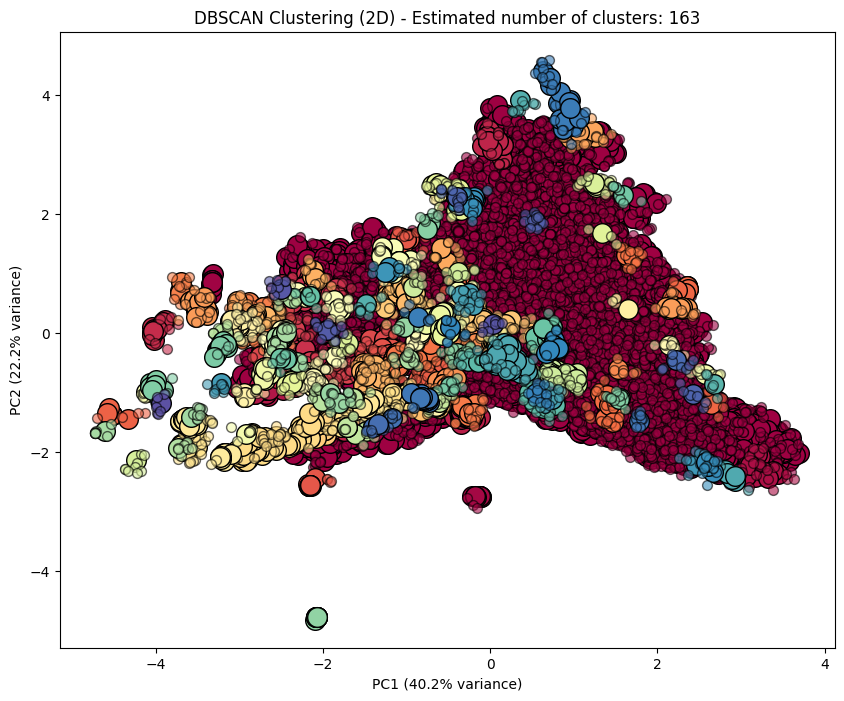

In [8]:
#Apply PCA to reduce to 2 dimensions for visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

#plotting the clusters in PCA space in 2D (hiding noise points)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

unique_labels = set(labels) #get unique cluster labels 
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))] #generate distinct colors for each cluster
for k, col in zip(unique_labels, colors):
    if k == -1:
        continue  # Skip noise points
    class_member_mask = (labels == k) #create a mask to identify points belonging to the current cluster
    xy = df_pca[class_member_mask & core_samples_mask] #get core samples of the current cluster
    ax.scatter(xy.iloc[:, 0], xy.iloc[:, 1], c=[tuple(col)], marker='o', s=200, edgecolors='k', label=f'Cluster {k} (core)') #plot core samples
    xy = df_pca[class_member_mask & ~core_samples_mask] #get non-core samples of the current cluster
    ax.scatter(xy.iloc[:, 0], xy.iloc[:, 1], c=[tuple(col)], marker='o', s=50, edgecolors='k', alpha=0.6) #plot non-core samples

ax.set_title('DBSCAN Clustering (2D) - Estimated number of clusters: %d' % n_clusters_) #set title with number of clusters
ax.set_xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.show() #display the plot


In [9]:
# Show feature contributions to principal components
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features.select_dtypes(include=[np.number]).columns
)

print("Feature Contributions to Principal Components:")
print("\nTop contributors to PC1:")
print(components_df['PC1'].abs().nlargest(5))
print("\nTop contributors to PC2:")
print(components_df['PC2'].abs().nlargest(5))

print("\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

Feature Contributions to Principal Components:

Top contributors to PC1:
formation_energy_peratom    0.550651
nat                         0.466268
optb88vdw_bandgap           0.415322
optb88vdw_total_energy      0.384736
ehull                       0.364240
Name: PC1, dtype: float64

Top contributors to PC2:
density                   0.744323
ehull                     0.402906
optb88vdw_total_energy    0.364906
optb88vdw_bandgap         0.361264
nat                       0.121339
Name: PC2, dtype: float64

Variance explained by each component:
PC1: 40.23%
PC2: 22.15%


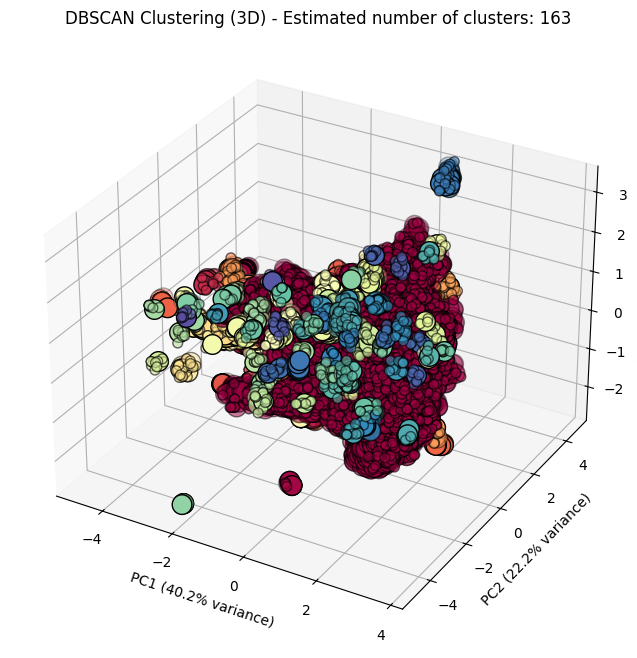

In [10]:
#Apply PCA to reduce to 3 dimensions for visualization
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])

#plotting the clusters in PCA space in 3D (hiding noise points)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

unique_labels = set(labels) #get unique cluster labels 
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))] #generate distinct colors for each cluster
for k, col in zip(unique_labels, colors):
    if k == -1:
        continue  # Skip noise points
    class_member_mask = (labels == k) #create a mask to identify points belonging to the current cluster
    xy = df_pca[class_member_mask & core_samples_mask] #get core samples of the current cluster
    ax.scatter(xy.iloc[:, 0], xy.iloc[:, 1], xy.iloc[:, 2], c=[tuple(col)], marker='o', s=200, edgecolors='k', label=f'Cluster {k} (core)') #plot core samples
    xy = df_pca[class_member_mask & ~core_samples_mask] #get non-core samples of the current cluster
    ax.scatter(xy.iloc[:, 0], xy.iloc[:, 1], xy.iloc[:, 2], c=[tuple(col)], marker='o', s=50, edgecolors='k', alpha=0.6) #plot non-core samples

ax.set_title('DBSCAN Clustering (3D) - Estimated number of clusters: %d' % n_clusters_) #set title with number of clusters
ax.set_xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
ax.set_zlabel('PC3 (%.1f%% variance)' % (pca.explained_variance_ratio_[2]*100))
plt.show() #display the plot


In [11]:
# Show feature contributions to principal components
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features.select_dtypes(include=[np.number]).columns
)

print("Feature Contributions to Principal Components:")
print("\nTop contributors to PC1:")
print(components_df['PC1'].abs().nlargest(5))
print("\nTop contributors to PC2:")
print(components_df['PC2'].abs().nlargest(5))
print("\nTop contributors to PC3:")
print(components_df['PC3'].abs().nlargest(5))

print("\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

Feature Contributions to Principal Components:

Top contributors to PC1:
formation_energy_peratom    0.550651
nat                         0.466268
optb88vdw_bandgap           0.415322
optb88vdw_total_energy      0.384736
ehull                       0.364240
Name: PC1, dtype: float64

Top contributors to PC2:
density                   0.744323
ehull                     0.402906
optb88vdw_total_energy    0.364906
optb88vdw_bandgap         0.361264
nat                       0.121339
Name: PC2, dtype: float64

Top contributors to PC3:
ehull                       0.708670
optb88vdw_total_energy      0.689208
nat                         0.114704
formation_energy_peratom    0.073861
density                     0.059716
Name: PC3, dtype: float64

Variance explained by each component:
PC1: 40.23%
PC2: 22.15%
PC3: 13.36%


In [16]:
!pip install plotly nbformat ipywidgets


   ----- ---------------------------------- 1/7 [rpds-py]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------------- 7/7 [nbformat]



'DOSKEY' is not recognized as an internal or external command,
operable program or batch file.


In [14]:
#Apply PCA to reduce to 3 dimensions for interactive visualization with Plotly
from sklearn.decomposition import PCA
import plotly.graph_objects as go

pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])

# Create traces for each cluster
fig = go.Figure()

unique_labels = set(labels)
colors_hex = [f'rgb{tuple([int(c*255) for c in plt.cm.Spectral(each)[:3]])}' 
              for each in np.linspace(0, 1, len(unique_labels))]

for k, col_hex in zip(sorted(unique_labels), colors_hex):
    if k == -1:
        continue  # Skip noise points for clarity
    class_member_mask = (labels == k)
    xy = df_pca[class_member_mask]
    
    # Separate core and non-core points
    is_core = core_samples_mask[class_member_mask]
    
    # Plot core samples
    core_points = xy[is_core]
    if len(core_points) > 0:
        fig.add_trace(go.Scatter3d(
            x=core_points['PC1'], y=core_points['PC2'], z=core_points['PC3'],
            mode='markers',
            name=f'Cluster {k} (core)',
            marker=dict(size=8, color=col_hex, opacity=1.0)
        ))
    
    # Plot non-core samples
    non_core_points = xy[~is_core]
    if len(non_core_points) > 0:
        fig.add_trace(go.Scatter3d(
            x=non_core_points['PC1'], y=non_core_points['PC2'], z=non_core_points['PC3'],
            mode='markers',
            name=f'Cluster {k}',
            marker=dict(size=4, color=col_hex, opacity=0.6)
        ))

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
fig.update_layout(
    title=f'DBSCAN Clustering (3D) - Estimated number of clusters: {n_clusters_}',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% variance)'
    ),
    width=1000,
    height=800
)
fig.show()
